<a href="https://colab.research.google.com/github/chiquixs/jobsheet/blob/main/data-mining/jobsheet7/abalone_logistic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving abalonedata.csv to abalonedata (2).csv
  Sex  Length  Diameter  Height  Whole weightShucked weight  Viscera weight  \
0   M   0.455     0.365   0.095                      0.5140          0.2245   
1   M   0.350     0.265   0.090                      0.2255          0.0995   
2   F   0.530     0.420   0.135                      0.6770          0.2565   
3   M   0.440     0.365   0.125                      0.5160          0.2155   
4   I   0.330     0.255   0.080                      0.2050          0.0895   

   Shell weight  Rings  Age  
0        0.1010  0.150   15  
1        0.0485  0.070    7  
2        0.1415  0.210    9  
3        0.1140  0.155   10  
4        0.0395  0.055    7  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Sex                         4177 non-null   object 
 1   Length           

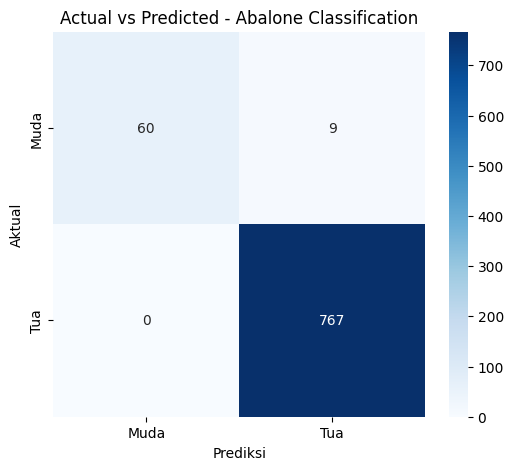

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from google.colab import files

uploaded = files.upload()
# Load dataset
data = pd.read_csv("abalonedata.csv")
print(data.head())

# Data Exploration
data.info()
print(data.describe())

# Preprocessing (Numerical to Binominal)
data['Status_Rings'] = np.where(data['Rings'] > 0.05, 1, 0)

# variabel Independen dan Dependen
# buang 'Age' dan 'Rings' asli (agar tidak bocor/leakage)
x = data.drop(['Rings', 'Age', 'Status_Rings'], axis=1)

# mengubah kolom 'Sex' (teks) menjadi angka agar bisa diproses Python
x = pd.get_dummies(x, columns=['Sex'], drop_first=True)

y = data['Status_Rings']

# Split Data (80% train, 20% test)
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)

# Train model (Logistic Regression)
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

# koefisien
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

# Prediction & Evaluation
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# isualization (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Muda', 'Tua'], yticklabels=['Muda', 'Tua'])
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Actual vs Predicted - Abalone Classification")
plt.show()